Complete code:

1. load data
- With batch_first=True, PyTorch LSTM expects 
- input shape: (batch_size/samples in a batch), seq_len, input_size/dim)
- output shape: (batch_size, seq_len, hidden_size/dim)
2. train, test, normalization/scaling
3. create sequential dataset (create as tensor dataset, seal in tensor loader)
4. create network class (layers in init, operations in forward), create object of model, loss and optimizer
5. training with epochs (train, eval)
6. with the trained model, plot train and test predictions

/Users/zhanmiaohuang/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


(144, 1)
Epoch 0: train RMSE 0.3360, test RMSE 0.9217
Epoch 200: train RMSE 0.0684, test RMSE 0.1646
Epoch 400: train RMSE 0.0676, test RMSE 0.1770
Epoch 600: train RMSE 0.0665, test RMSE 0.1694
Epoch 800: train RMSE 0.0661, test RMSE 0.1735
Epoch 1000: train RMSE 0.0654, test RMSE 0.1797
Epoch 1200: train RMSE 0.0647, test RMSE 0.1785
Epoch 1400: train RMSE 0.0638, test RMSE 0.1766
Epoch 1600: train RMSE 0.0634, test RMSE 0.1783
Epoch 1800: train RMSE 0.0631, test RMSE 0.1758


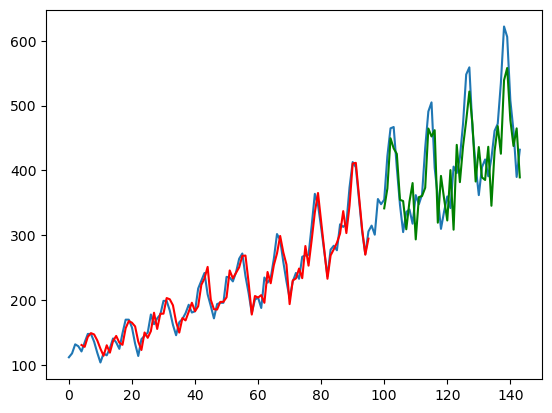

RMSE: 0.16


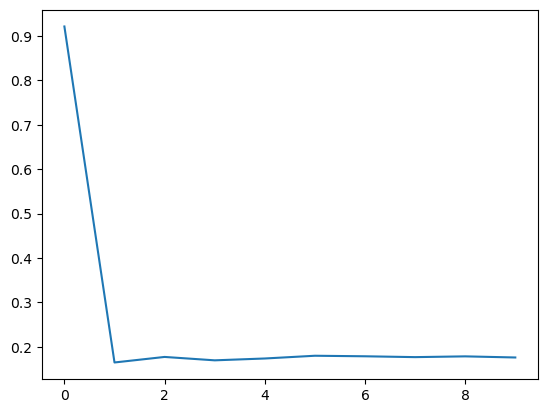

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
from sklearn.preprocessing import MinMaxScaler
import copy

torch.manual_seed(0)

# df = pd.read_csv('airline-passengers.csv')
df = pd.read_csv('https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv')
timeseries = df[["Passengers"]].values.astype('float32')
print(timeseries.shape)

# train-test split for time series
train_size = int(len(timeseries) * 0.67)
test_size = len(timeseries) - train_size
train, test = timeseries[:train_size], timeseries[train_size:]


scaler = MinMaxScaler(feature_range=(0, 1))
train = scaler.fit_transform(train)
test = scaler.transform(test)

def create_dataset(dataset, lookback):
    """Transform a time series into a prediction dataset
    Args:
        dataset: A numpy array of time series, first dimension is the time steps
        lookback: Size of window for prediction
    """
    
    X, y = [], []
    for i in range(len(dataset)-lookback):
        feature = dataset[i:i+lookback]
        target = dataset[i+1:i+lookback+1]
        X.append(feature)
        y.append(target)
    return torch.tensor(np.array(X)), torch.tensor(np.array(y))

lookback = 4
X_train, y_train = create_dataset(train, lookback=lookback)
X_test, y_test = create_dataset(test, lookback=lookback)

class AirModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=50, num_layers=1, batch_first=True)
        self.linear = nn.Linear(50, 1)
    def forward(self, x):
        x, _ = self.lstm(x)
        x = self.linear(x)
        return x

model = AirModel()
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

dataset = data.TensorDataset(X_train, y_train)
loader = data.DataLoader(dataset, shuffle=True, batch_size=8)

history = []
best_rmse = 0.17
n_epochs = 2000
for epoch in range(n_epochs):
    model.train()
    for X_batch, y_batch in loader:
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Validation
    if epoch % 200 != 0:
        continue

    model.eval()
    with torch.no_grad():
        y_pred = model(X_train)
        train_rmse = np.sqrt(loss_fn(y_pred, y_train))
        y_pred = model(X_test)
        test_rmse = np.sqrt(loss_fn(y_pred, y_test))
        history.append(test_rmse)
    print("Epoch %d: train RMSE %.4f, test RMSE %.4f" % (epoch, train_rmse, test_rmse))

    # early stopping, and keep the best model parameters
    if test_rmse < best_rmse:
        best_rmse = test_rmse
        best_params = copy.deepcopy(model.state_dict())


with torch.no_grad():
    # shift train predictions for plotting
    train_plot = np.ones_like(timeseries) * np.nan
    y_pred = model(X_train)
    y_pred = y_pred[:, -1, :]
    train_plot[lookback:train_size] = scaler.inverse_transform(y_pred)

    # shift test predictions for plotting
    test_plot = np.ones_like(timeseries) * np.nan
    test_plot[train_size+lookback:len(timeseries)] = scaler.inverse_transform(model(X_test)[:, -1, :])

# plot
plt.plot(timeseries)
plt.plot(train_plot, c='r')
plt.plot(test_plot, c='g')
plt.show()

# restore the best model
model.load_state_dict(best_params)
print("RMSE: %.2f" % best_rmse)
plt.plot(history)


In [16]:
print(X_batch.shape)
print(y_batch.shape)
y_pred = model(X_batch)
print(y_pred.shape)

torch.Size([4, 4, 1])
torch.Size([4, 4, 1])
torch.Size([4, 4, 1])


Usage of LSTM, size of input:

In [3]:
import torch
import torch.nn as nn

In [4]:
import numpy as np

In [11]:
# transform list of tensors to a single tensor

inputs = [torch.randn(1, 3) for _ in range(5)]
print(len(inputs), inputs[0].shape)
print(inputs)
# print(inputs.shape) error # list没有shape属性

inputs = torch.cat(inputs)#.view(len(inputs), 1, -1)  # 将list[0] [1]...依次排列成一个大tensor
print(inputs.shape)
print(inputs)

inputs = [torch.randn(1, 3) for _ in range(5)]
inputs = torch.stack(inputs)#.view(len(inputs), 1, -1)
print(inputs.shape)
print(inputs)


5 torch.Size([1, 3])
[tensor([[ 0.5921, -0.2975,  0.4264]]), tensor([[ 0.3237, -0.0365,  1.5130]]), tensor([[ 0.6185, -0.9733, -0.4832]]), tensor([[-0.1537, -2.5189,  0.0800]]), tensor([[-2.0421, -0.2467, -0.2862]])]
torch.Size([5, 3])
tensor([[ 0.5921, -0.2975,  0.4264],
        [ 0.3237, -0.0365,  1.5130],
        [ 0.6185, -0.9733, -0.4832],
        [-0.1537, -2.5189,  0.0800],
        [-2.0421, -0.2467, -0.2862]])
torch.Size([1, 5, 3])
tensor([[[ 0.2640, -0.2385,  0.5275],
         [ 2.7076, -0.5327, -0.8578],
         [ 1.2154, -1.0505, -0.2758],
         [-1.0064, -0.4467,  0.9614],
         [ 0.0665, -1.3402, -0.6934]]])


In [15]:
a = np.array([1,2,3]).reshape(3,-1)
b = np.array([4,5,6,7,8,9]).reshape(3,-1)
print(np.concatenate([a,b], axis=1))  # 指定axis被joined，其他axes的dim应相同
print(np.concatenate([a,b], axis=None))  # axis=None时，展开成一维数组再连接


[[1 4 5]
 [2 6 7]
 [3 8 9]]
[1 2 3 4 5 6 7 8 9]


In [47]:
lstm = nn.LSTM(input_size=3, hidden_size=2, batch_first=True)  # 输入维度为3维(也称为feature)，输出维度为3维

inputs = [torch.randn(1, 3) for _ in range(5)]  # 生成一个长度为5的序列
seq_len = len(inputs)
inputs = torch.cat(inputs).view(1, seq_len, -1)  # 将list[0] [1]...依次排列成一个大tensor 
# batch_first=True时，input size: (batch_size=1, seq_len=5, input_dim=3)
# default input size: (seq_len, batch_size, input_dim) 
# Inputs: input, (h_0, c_0)
# If (h_0, c_0) is not provided, defaults to zeros.

hidden = (torch.randn(1, 1, 2), torch.randn(1, 1, 2))  # 初始化hidden state and cell state

out, (hn, cn) = lstm(inputs, hidden)
# Outputs: output, (h_n, c_n) 
print(out, out.shape)  # (batch_size=1, seq_len=5, hidden_size=2)
# print(hidden) 
# hn, cn = hidden 
print(hn, hn.shape) # 最后一个时刻的hidden state (batch_size=1, seq_len=1, hidden_size=2)
print(cn, cn.shape)

# LSTM第一个返回值out是所有时刻的隐藏状态
# 第二个返回值hidden是最后一个时刻的隐藏状态
# 之所以这样设计:
# 通过"out"你能取得任何一个时刻的隐藏状态，
#而"hidden"的值是用来进行序列的反向传播运算, 具体方式就是将它作为参数传入后面的 LSTM 网络.


tensor([[[ 0.0531, -0.3442],
         [ 0.0861, -0.1782],
         [ 0.1536, -0.5957],
         [ 0.2022, -0.5585],
         [ 0.1836, -0.5415]]], grad_fn=<TransposeBackward0>) torch.Size([1, 5, 2])
tensor([[[ 0.1836, -0.5415]]], grad_fn=<StackBackward0>) torch.Size([1, 1, 2])
tensor([[[ 0.4543, -1.3062]]], grad_fn=<StackBackward0>) torch.Size([1, 1, 2])


Use dataset in LSTM:
https://machinelearningmastery.com/lstm-for-time-series-prediction-in-pytorch/?utm_source=chatgpt.com

Dataset link:
https://github.com/jbrownlee/Datasets

cell memory c (long-term memory), hidden state h (short-term memory)

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [68]:
df = pd.read_csv('https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv')
# df = pd.read_csv('airline-passengers.csv')

# 查看基本结构
df.head()
df.tail()
df.shape
print(df.info())  # 查看数据类型，是否有缺失
df.describe()

# 访问行/列
df['Passengers']  # 选一列
df[['Month', 'Passengers']]  # 选多列
df.iloc[0]  # 第一行（按位置）
df.iloc[:, 0]  # 第一列
df.loc[0]  # 第一行（按标签）
# df.loc[:, 'Month']  # Month列

# 基本清洗
# df = df.rename(columns={'Passengers': 'P'}) # 或者还可以重命名index
df = df.dropna()  # 删除缺失值 (remove the index row with missing values)
df['Passengers'] = df['Passengers'].fillna(method='ffill')  # 或者，前向填充缺失值
# pd.to_datetime(df['Month'])  # 转换为日期时间格式

# 排序/索引设置
# df = df.sort_values(by='Month', ascending=True)  # 按 Month 列排序
# df = df.set_index('Month')  # 把 Month 列设置为索引

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Month       144 non-null    object
 1   Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB
None


,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [23]:
df0 = pd.DataFrame([[np.nan, 2, np.nan, 0],
                    [3, 4, np.nan, 1],
                    [np.nan, np.nan, np.nan, np.nan],
                    [np.nan, 3, np.nan, 4]],
                   columns=list("ABCD"))
# df0.fillna(0)
print(df0)
df0.fillna(method='ffill', axis=0)  # 按行前向填充

     A    B   C    D
0  NaN  2.0 NaN  0.0
1  3.0  4.0 NaN  1.0
2  NaN  NaN NaN  NaN
3  NaN  3.0 NaN  4.0


,A,B,C,D
0,NaN,2.0,NaN,0.0
1,3.0,4.0,NaN,1.0
2,3.0,4.0,NaN,1.0
3,3.0,3.0,NaN,4.0


In [29]:
# df['Passengers']（单括号） → 返回 Series（1D）
# df[['Passengers']]（双括号） → 返回 DataFrame（2D）
# 再用.values转成numpy数组

print(df['Passengers'].head(),'\n')  # (144,) 
print(df[['Passengers']].head())  # (144, 1) 意为取[['P']]这一列，所以返回144行 1列
print(df[['Passengers']].values[0:3])  

Month
1949-01    112
1949-02    118
1949-03    132
1949-04    129
1949-05    121
Name: Passengers, dtype: int64 

         Passengers
Month              
1949-01         112
1949-02         118
1949-03         132
1949-04         129
1949-05         121
[[112]
 [118]
 [132]]


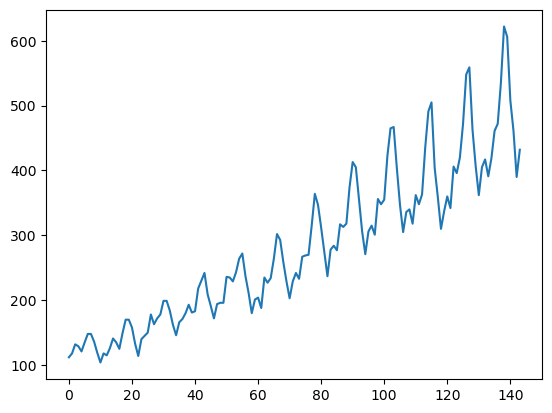

In [69]:
timeseries = df[['Passengers']].values.astype('float32') # default torch dtype is float32
plt.plot(timeseries)
plt.show()

In [50]:
timeseries.shape  # 如果input_dim=1，要手动.unsqueeze(-1)在最后一维加上一个维度

(144, 1)

LSTMs are sensitive to the scale of the input data, specifically when the sigmoid (default) or tanh activation functions are used. \
It can be a good practice to rescale the data to the range of 0-to-1.
- after scalar.fit_transform, we need scalar.inverse_transform to the predicted data.

In [51]:
from sklearn.preprocessing import MinMaxScaler

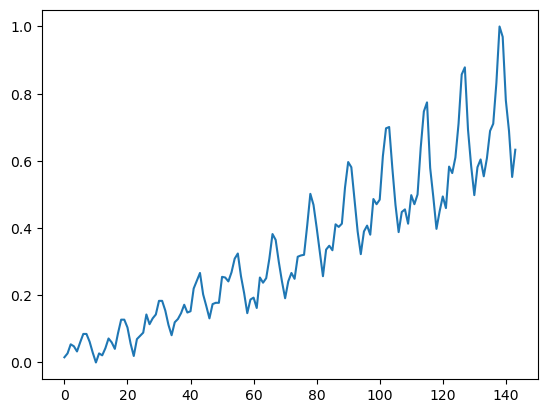

In [70]:
# normalize the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
timeseries = scaler.fit_transform(timeseries)
plt.plot(timeseries)
plt.show()

67% of the observations used to train the model, leaving the remaining 33% for testing the model

In [71]:
train_size = int(len(timeseries) * 0.67)
test_size = len(timeseries) - train_size
train, test = timeseries[:train_size], timeseries[train_size:]

In [55]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data

In [72]:
torch.manual_seed(0)

In [73]:
def create_dataset(dataset, lookback):
    ''' 
    Transform a time series into a prediction dataset. Given data from time t-w to t, predict for t+1.
    Args:
        dataset: A numpy array of time series
        lookback: Size of window (w) for prediction
    '''

    X, y = [], []
    for t in range(len(dataset)-lookback):
        feature = dataset[t:t+lookback]  # eg, lookback=2, input (t, t+1), target (t+1, t+2), seq_len=2 for each sample
        target = dataset[t+1:t+lookback+1]  # interested in t+3 (next step of input), but t+1 and t+2 useful in training
        X.append(feature)
        y.append(target)
    
    X, y = np.array(X), np.array(y)
    return torch.tensor(X), torch.tensor(y)

In [40]:
x = np.array([1.,2.,3.])
y = np.array([2.,3.,4.])
z = []
z.append(x)
z.append(y)
u = np.array(z)
u, u.shape


(array([[1., 2., 3.],
        [2., 3., 4.]]),
 (2, 3))

In [82]:
x = torch.tensor([1.,2.,3.])
x.unsqueeze(-1).shape # 在最后一维增加一个维度
# x.reshape(-1, 1).shape  # 变成二维，行数自动计算
x.unsqueeze(0).shape  # 在第0维增加一个维度
x.squeeze().shape  # 去掉所有维度为1的维度

torch.Size([3])

In [74]:
lookback = 1
X_train, y_train = create_dataset(train, lookback=lookback)
X_test, y_test = create_dataset(test, lookback=lookback)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)
# (sliding window samples, seq_len/time_steps, features/input_size/input_dim)
# 这里的seq_len/time_steps指的是每一个sample进入lstm所包含的时间步数，这里即是=lookback

# With batch_first=True, PyTorch LSTM expects 
# input shape: (batch_size/samples in a batch), seq_len, input_size/dim)
# output shape: (batch_size, seq_len, hidden_size/dim)

# 如果train和test数据本身是一维数组，
# we can explicitly reshape to (samples, seq_len, input_dim)
# 或者在一开始获得数据时就保持二维格式，如.unsqueeze(-1)在最后一维增加一个维度
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)   # input_dim=1
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
y_train = y_train.reshape(y_train.shape[0], y_train.shape[1], 1)  # output_features=1 in the last linear layer
y_test = y_test.reshape(y_test.shape[0], y_test.shape[1], 1)
print('After reshaping:')
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([95, 1, 1]) torch.Size([95, 1, 1])
torch.Size([47, 1, 1]) torch.Size([47, 1, 1])
After reshaping:
torch.Size([95, 1, 1]) torch.Size([95, 1, 1])
torch.Size([47, 1, 1]) torch.Size([47, 1, 1])


In [75]:
class AirModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=50, num_layers=1, batch_first=True)
        self.linear = nn.Linear(in_features=50, out_features=1)

    def forward(self, x):
        x, _ = self.lstm(x)  # x: (batch, seq_len, hidden_size), output _ is final hidden state and final cell state
        # x = x[:, -1, :] # take only the last time step's output
        x = self.linear(x)
        return x

torch.utils.data: 
1. 创建Dataset，通过TensorDataset
2. 依赖DataLoader将dataset组织成batch，不需要手动切分 (Pytorch的DataLoader只能从Dataset中读取数据)

DataLoader: 自动把dataset分成batch，自动打乱数据shuffule=True，自动把tensor组成为batch (X_batch, y_batch)，
可以并行加载，每次迭代返回一个batch（for X_batch, y_batch in loader: ...）

- epoch：完整遍历一次全部训练数据
- number of batch（minibatch）：把数据按小块分批训练
- batch_size：每个 batch 含多少样本

In [3]:
# 使用示例：

X = torch.randn(100, 10)  # 100 samples, 10 features (feature=input size)
y = torch.randn(100, 1)

dataset = data.TensorDataset(X, y)
loader = data.DataLoader(dataset, batch_size=8, shuffle=True)

for X_batch, y_batch in loader:
    print(X_batch.shape, y_batch.shape)

# 100个样本被分成若干个batch，每个batch包含8个样本（最后一个batch只剩4个）
    
# DataLoader 只负责把样本堆叠成 batch，给出(batch_size, seq_len, features)
# 几乎所有深度学习项目都需要设置batch_first=True

torch.Size([8, 10]) torch.Size([8, 1])
torch.Size([8, 10]) torch.Size([8, 1])
torch.Size([8, 10]) torch.Size([8, 1])
torch.Size([8, 10]) torch.Size([8, 1])
torch.Size([8, 10]) torch.Size([8, 1])
torch.Size([8, 10]) torch.Size([8, 1])
torch.Size([8, 10]) torch.Size([8, 1])
torch.Size([8, 10]) torch.Size([8, 1])
torch.Size([8, 10]) torch.Size([8, 1])
torch.Size([8, 10]) torch.Size([8, 1])
torch.Size([8, 10]) torch.Size([8, 1])
torch.Size([8, 10]) torch.Size([8, 1])
torch.Size([4, 10]) torch.Size([4, 1])


In [76]:
model = AirModel()
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

dataset = data.TensorDataset(X_train, y_train)
loader = data.DataLoader(dataset, shuffle=True, batch_size=8)

n_epochs = 2000
for epoch in range(n_epochs):

    model.train()
    for X_batch, y_batch in loader:
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if epoch % 200 != 0:
        continue

    model.eval()
    with torch.no_grad():
        y_pred = model(X_train)
        train_rmse = np.sqrt(loss_fn(y_pred, y_train))
        y_pred = model(X_test)
        test_rmse = np.sqrt(loss_fn(y_pred, y_test))
    print(f'Epoch {epoch}: train RMSE {train_rmse:.4f}, test RMSE {test_rmse:.4f}')

Epoch 0: train RMSE 0.2005, test RMSE 0.5482
Epoch 200: train RMSE 0.0446, test RMSE 0.0954
Epoch 400: train RMSE 0.0441, test RMSE 0.0938
Epoch 600: train RMSE 0.0442, test RMSE 0.0949
Epoch 800: train RMSE 0.0441, test RMSE 0.0970
Epoch 1000: train RMSE 0.0441, test RMSE 0.1023
Epoch 1200: train RMSE 0.0441, test RMSE 0.0988
Epoch 1400: train RMSE 0.0441, test RMSE 0.0989
Epoch 1600: train RMSE 0.0439, test RMSE 0.0995
Epoch 1800: train RMSE 0.0440, test RMSE 0.1036


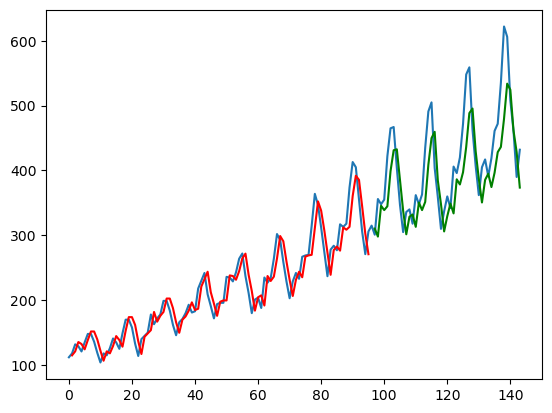

In [78]:
with torch.no_grad():
    # train predictions
    y_pred = model(X_train)  # (batch, seq_len, hidden_size)
    y_pred = y_pred[:, -1, :]
    train_plot = np.ones_like(timeseries) * np.nan
    train_plot[lookback:train_size] = scaler.inverse_transform(y_pred)

    # test predictions
    y_pred = model(X_test)
    y_pred = y_pred[:, -1, :]
    test_plot = np.ones_like(timeseries) * np.nan
    test_plot[train_size+lookback:len(timeseries)] = scaler.inverse_transform(y_pred)
    
plt.plot(scaler.inverse_transform(timeseries))
plt.plot(train_plot, c='r')
plt.plot(test_plot, c='g')
plt.show()

In [18]:
np.empty((5,))*np.nan

array([nan, nan, nan, nan, nan])

Use random generated data:
https://www.geeksforgeeks.org/deep-learning/long-short-term-memory-networks-using-pytorch/?utm_source=chatgpt.com

(similar framework as above; we can refer to the above one only.)